In [6]:
import json

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd

from allium_cepa_classifier.config.base_config import find_project_root

ROOT = find_project_root()
experiments_dir = ROOT / "experiments"

records = []
for metrics_path in sorted(experiments_dir.glob("*/metrics.json")):
    data = json.loads(metrics_path.read_text())
    data["run_name"] = metrics_path.parent.name
    records.append(data)

print(f"Found {len(records)} experiment runs")
for r in records:
    print(f"  {r['run_name']}")

Found 4 experiment runs
  20260503-161453_efficientnet_b1_baseline
  20260503-161725_efficientnet_b2_baseline
  20260503-162007_resnet50_baseline
  20260503-162914_vgg19_baseline


In [7]:
rows = [
    {
        "run_name": r["run_name"],
        "test_acc": r.get("test_acc"),
        "val_acc": r.get("val_acc"),
        "train_acc": r.get("train_acc"),
        "epochs_run": r.get("epochs_run"),
        "ece_before": r.get("ece_before"),
        "ece_after": r.get("ece_after"),
    }
    for r in records
]
df = pd.DataFrame(rows).sort_values("test_acc", ascending=False).reset_index(drop=True)
df

,run_name,test_acc,val_acc,train_acc,epochs_run,ece_before,ece_after
0,20260503-162914_vgg19_baseline,0.846556,0.823044,0.798775,3,NaN,NaN
1,20260503-161725_efficientnet_b2_baseline,0.830328,0.822529,0.796500,3,0.034606,0.029023
2,20260503-161453_efficientnet_b1_baseline,0.803101,0.791984,0.786899,3,0.055838,0.038665
3,20260503-162007_resnet50_baseline,0.782185,0.805258,0.695840,3,0.118649,0.082869


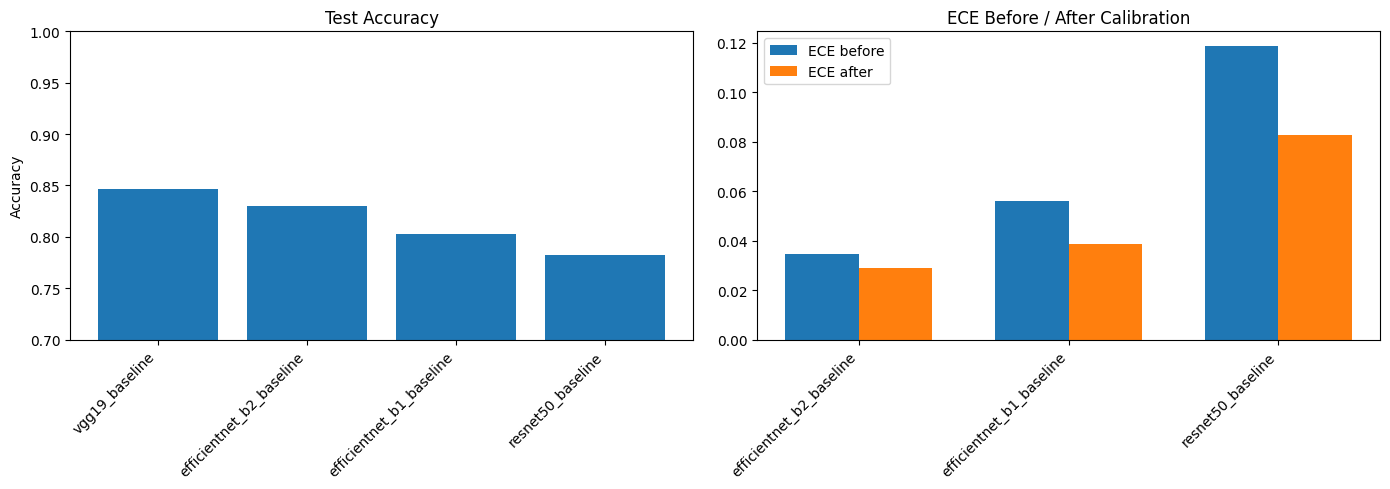

In [8]:
def _short(run_name: str) -> str:
    """Strip timestamp prefix from run name for readability."""
    parts = run_name.split("_", 1)
    return parts[1] if len(parts) > 1 else run_name


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(df))
tick_labels = [_short(n) for n in df["run_name"]]

axes[0].bar(x, df["test_acc"])
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(tick_labels, rotation=45, ha="right")
axes[0].set_ylim(0.7, 1.0)
axes[0].set_title("Test Accuracy")
axes[0].set_ylabel("Accuracy")

ece_df = df.dropna(subset=["ece_before", "ece_after"])
if not ece_df.empty:
    bx = range(len(ece_df))
    width = 0.35
    axes[1].bar([i - width / 2 for i in bx], ece_df["ece_before"], width, label="ECE before")
    axes[1].bar([i + width / 2 for i in bx], ece_df["ece_after"], width, label="ECE after")
    axes[1].set_xticks(list(bx))
    axes[1].set_xticklabels([_short(n) for n in ece_df["run_name"]], rotation=45, ha="right")
    axes[1].set_title("ECE Before / After Calibration")
    axes[1].legend()
else:
    axes[1].text(
        0.5, 0.5, "No calibrated runs yet", ha="center", va="center", transform=axes[1].transAxes
    )
    axes[1].set_title("ECE Before / After Calibration")

plt.tight_layout()
plt.show()

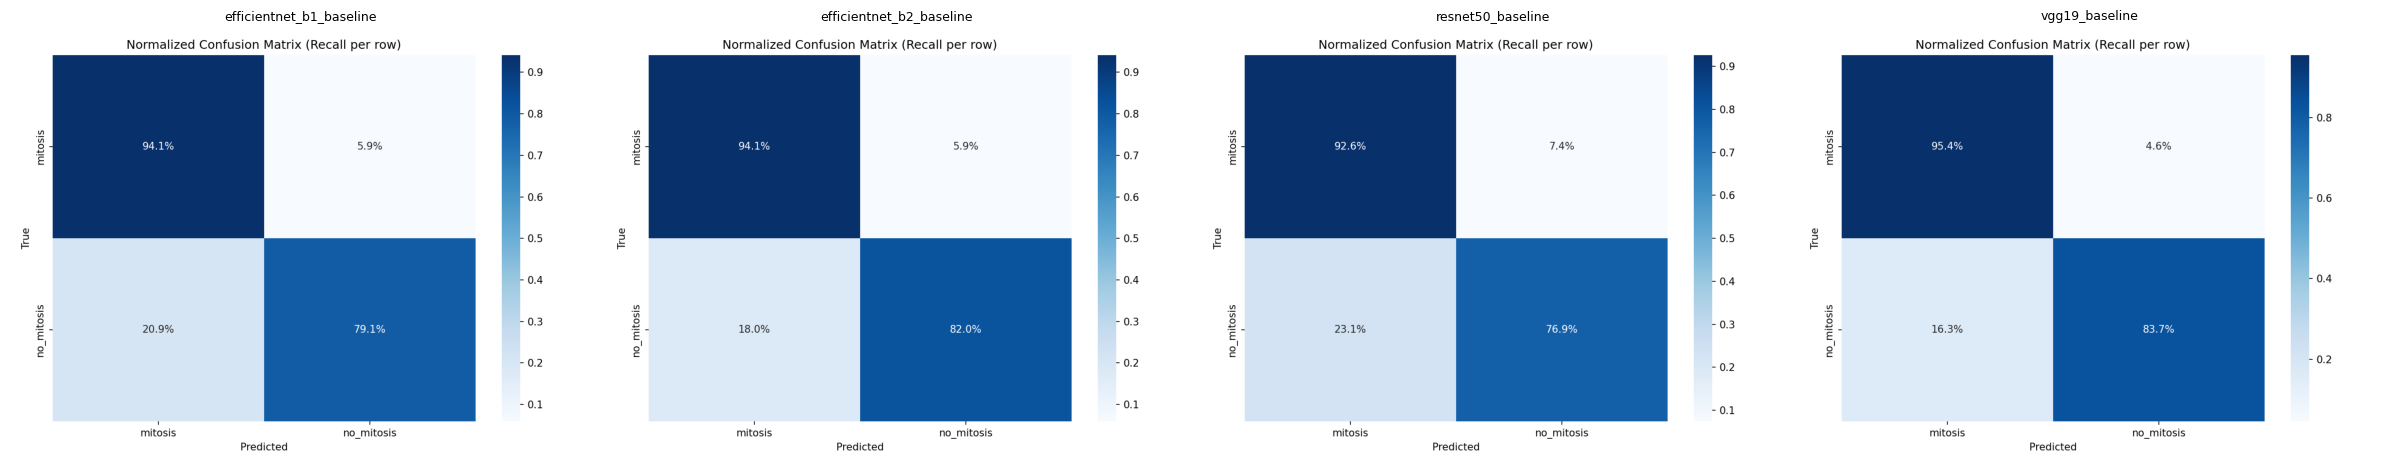

In [9]:
cm_paths = [
    (r["run_name"], experiments_dir / r["run_name"] / "plots" / "confusion_matrix.png")
    for r in records
    if (experiments_dir / r["run_name"] / "plots" / "confusion_matrix.png").exists()
]

if cm_paths:
    n = len(cm_paths)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, (name, path) in zip(axes, cm_paths):
        ax.imshow(mpimg.imread(path))
        ax.set_title(_short(name), fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No confusion matrices found.")

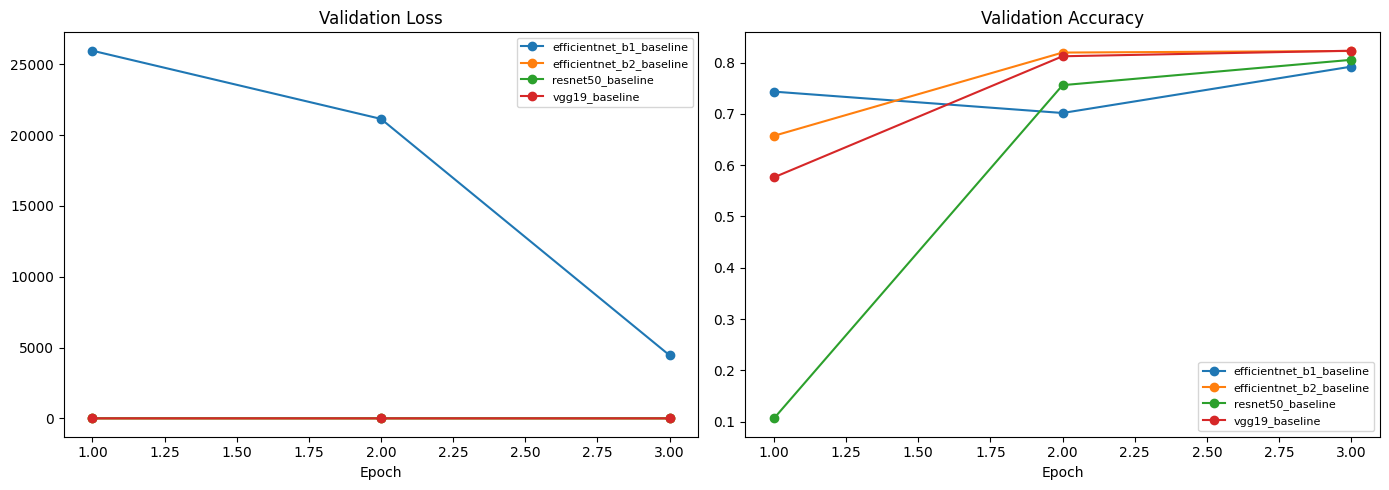

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for r in records:
    history = r.get("history", {})
    if not history.get("val_loss"):
        continue
    label = _short(r["run_name"])
    epochs = range(1, len(history["val_loss"]) + 1)
    axes[0].plot(epochs, history["val_loss"], marker="o", label=label)
    axes[1].plot(epochs, history["val_acc"], marker="o", label=label)

axes[0].set_title("Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend(fontsize=8)
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()